In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score

In [3]:
# Load the CICIDS 2017 dataset
# Replace with the correct path where the CICIDS 2017 dataset is stored
data = pd.read_csv("cicids2017_cleaned.csv")

In [4]:
data.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.97561,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.97561,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.00000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [5]:
data.shape

(2520751, 53)

In [6]:
data.info

<bound method DataFrame.info of          Destination Port  Flow Duration  Total Fwd Packets  \
0                      22        1266342                 41   
1                      22        1319353                 41   
2                      22            160                  1   
3                      22        1303488                 41   
4                   35396             77                  1   
...                   ...            ...                ...   
2520746                53          32215                  4   
2520747                53            324                  2   
2520748             58030             82                  2   
2520749                53        1048635                  6   
2520750                53          94939                  4   

         Total Length of Fwd Packets  Fwd Packet Length Max  \
0                               2664                    456   
1                               2664                    456   
2                     

In [7]:
data.describe

<bound method NDFrame.describe of          Destination Port  Flow Duration  Total Fwd Packets  \
0                      22        1266342                 41   
1                      22        1319353                 41   
2                      22            160                  1   
3                      22        1303488                 41   
4                   35396             77                  1   
...                   ...            ...                ...   
2520746                53          32215                  4   
2520747                53            324                  2   
2520748             58030             82                  2   
2520749                53        1048635                  6   
2520750                53          94939                  4   

         Total Length of Fwd Packets  Fwd Packet Length Max  \
0                               2664                    456   
1                               2664                    456   
2                   

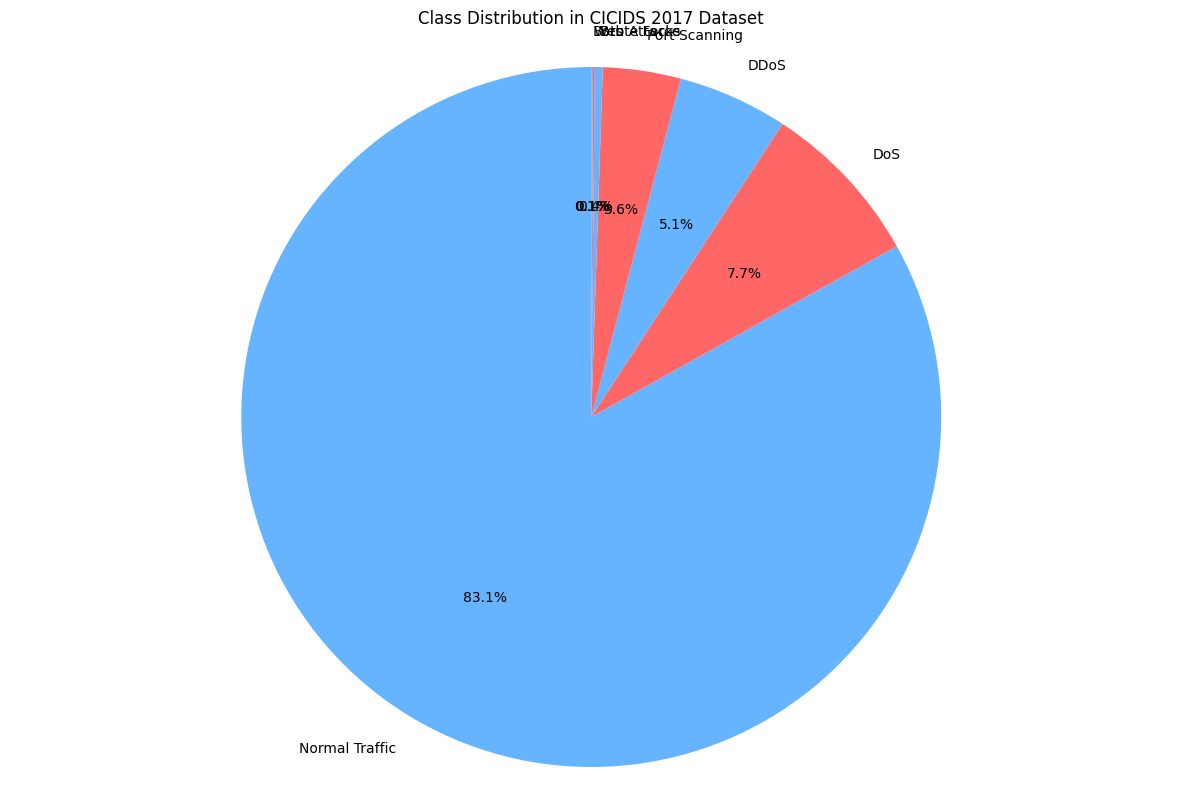

In [12]:
# Check the distribution of the 'Label' column (assuming 'Label' is the target)
label_counts = data['Attack Type'].value_counts()

# Plot a pie chart for the 'Label' column
plt.figure(figsize=(15, 10))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff6666'])
plt.title('Class Distribution in CICIDS 2017 Dataset')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

In [15]:
# Assuming 'Label' is the target column, and the rest are features
X = data.drop(columns=['Attack Type'])
y = data['Attack Type']

In [16]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
# Define the model
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
}

# Create a LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Train the model
model = lgb.train(params, train_data, 100, valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=10)])

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_binary = np.round(y_pred)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred)
average_precision = average_precision_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' % average_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Attack Type: object